# 05 — Scoring en Vivo

Scoring de mercados activos para el modelo tabular actual del repo.

Este notebook ya no usa el contrato viejo de `model_score` crudo. Ahora trabaja sobre los artefactos del scorer actual:
- `p_yes_calibrated`
- `ev_per_share`
- `expected_roi_capped`
- `signal`

Secciones:
1. Cargar artefactos del modelo tabular
2. Leer scoring live actual
3. Top-K señales con EV y ROI capped
4. Filtros de calidad y distribución de señales
5. Lectura del desempeño offline en test
6. Resumen operativo


In [7]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
MODELS = ROOT / 'data' / 'models'
REGISTRY = MODELS / 'registry'
MODEL_NAME = 'market_value_baseline'

comparison = json.loads((REGISTRY / 'model_comparison.json').read_text())
live_df = pd.read_csv(REGISTRY / 'live_scores.csv')
live_summary = json.loads((REGISTRY / 'live_scoring_summary.json').read_text())
test_metrics = comparison['models'][MODEL_NAME]['test']

df_scores = live_df[live_df['model_name'] == MODEL_NAME].copy().sort_values('ev_per_share', ascending=False)
print(f'Modelo: {MODEL_NAME}')
print(f'Rows live: {len(df_scores):,}')


Modelo: market_value_baseline
Rows live: 534


## 1. Cargar modelo y pipeline

In [8]:
display(pd.Series(live_summary[MODEL_NAME]))
print('\nResumen test offline:')
print(json.dumps({
    'brier': test_metrics['calibrated_metrics']['brier'],
    'market_brier': test_metrics['market_baseline_metrics']['brier'],
    'top_k_avg_realized_pnl': test_metrics['ev_metrics']['top_k_avg_realized_pnl'],
    'top_k_hit_rate': test_metrics['ev_metrics']['top_k_hit_rate'],
}, indent=2))


count                                                                534
signals                        {'HOLD': 492, 'STRONG BUY': 38, 'BUY': 4}
p_yes_calibrated       {'p10': 0.009462151394422311, 'p50': 0.4382470...
ev_per_share           {'p10': 0.003962151424224633, 'p50': 0.2856640...
expected_roi           {'p10': 0.0629567170515816, 'p50': 7.259495511...
expected_roi_capped    {'p10': 0.0629567170515816, 'p50': 5.0, 'p90':...
dtype: object


Resumen test offline:
{
  "brier": 0.011083147926757702,
  "market_brier": 0.0061812073153345365,
  "top_k_avg_realized_pnl": 0.02667499713425059,
  "top_k_hit_rate": 0.15
}


## 2. Puntuar mercados activos

El scoring ya está guardado en `data/models/registry/live_scores.csv`. Eso evita reejecutar inferencia cada vez que abres el notebook y mantiene consistencia con `src.scoring.scorer`.


In [9]:
cols = [
    'question', 'price_yes', 'p_yes_calibrated', 'ev_per_share',
    'expected_roi', 'expected_roi_capped', 'days_to_end', 'signal'
]
print(f'Mercados cargados para {MODEL_NAME}: {len(df_scores):,}')
df_scores[cols].head(10)


Mercados cargados para market_value_baseline: 534


,question,price_yes,p_yes_calibrated,ev_per_share,expected_roi,expected_roi_capped,days_to_end,signal
0,Will Gavin Newsom win the 2028 Democratic pres...,0.2410,0.985540,0.744540,3.089379,3.089379,938.882304,HOLD
1,Will JD Vance win the 2028 US Presidential Ele...,0.1765,0.818182,0.641682,3.635591,3.635591,938.882304,HOLD
2,Will Kim Kardashian win the 2028 US Presidenti...,0.0045,0.637860,0.633360,140.746691,5.000000,938.882304,HOLD
8,Will Bernie Sanders win the 2028 Democratic pr...,0.0055,0.637860,0.632360,114.974561,5.000000,938.882304,HOLD
12,Will Kim Kardashian win the 2028 Republican pr...,0.0055,0.637860,0.632360,114.974561,5.000000,938.882304,HOLD
11,Will Pete Hegseth win the 2028 US Presidential...,0.0055,0.637860,0.632360,114.974561,5.000000,938.882304,HOLD
9,Will Eric Trump win the 2028 US Presidential E...,0.0055,0.637860,0.632360,114.974561,5.000000,938.882304,HOLD
10,Will LeBron James win the 2028 US Presidential...,0.0055,0.637860,0.632360,114.974561,5.000000,938.882304,HOLD
7,Will Erika Kirk win the 2028 Republican presid...,0.0055,0.637860,0.632360,114.974561,5.000000,938.882304,HOLD
6,Will Hunter Biden win the 2028 Democratic pres...,0.0055,0.637860,0.632360,114.974561,5.000000,938.882304,HOLD


## 3. Top-K señales con EV

A diferencia del notebook viejo, aquí la señal ya está construida sobre `ev_per_share` y `expected_roi_capped`, no sobre thresholds directos de score.


In [10]:
signal_counts = df_scores['signal'].value_counts().reindex(['STRONG BUY', 'BUY', 'HOLD'], fill_value=0)
print('Distribución de señales:')
for signal, count in signal_counts.items():
    print(f'  {signal:12s}: {count:,} ({100 * count / len(df_scores):.1f}%)')

print('\n' + '-' * 140)
print(f"{'#':>3} {'SEÑAL':12} {'PRECIO':>7} {'P_YES':>7} {'EV':>8} {'ROI_CAP':>8} {'DTE':>6} QUESTION")
print('-' * 140)
top_signals = df_scores[df_scores['signal'] != 'HOLD'].head(20)
for idx, (_, row) in enumerate(top_signals.iterrows(), 1):
    question = row['question'][:70]
    print(
        f"{idx:>3} {row['signal']:12} ${row['price_yes']:.2f}  {row['p_yes_calibrated']:.3f}  "
        f"{row['ev_per_share']:+.3f}  {row['expected_roi_capped']:+.3f}  {row['days_to_end']:>5.1f}  {question}"
    )


Distribución de señales:
  STRONG BUY  : 38 (7.1%)
  BUY         : 4 (0.7%)
  HOLD        : 492 (92.1%)

--------------------------------------------------------------------------------------------------------------------------------------------
  # SEÑAL         PRECIO   P_YES       EV  ROI_CAP    DTE QUESTION
--------------------------------------------------------------------------------------------------------------------------------------------
  1 STRONG BUY   $0.08  0.367  +0.287  +3.614   16.9  Will Trump declare war on Iran by April 30, 2026?
  2 STRONG BUY   $0.09  0.367  +0.282  +3.315   16.9  Will Trump say "Trump University" in April?
  3 STRONG BUY   $0.14  0.404  +0.269  +1.996   18.0  Will Ethereum dip to $1,600 in April?
  4 STRONG BUY   $0.17  0.438  +0.263  +1.504   16.9  Iran x Israel/US conflict ends by April 30?
  5 STRONG BUY   $0.05  0.305  +0.260  +5.000   18.0  Will WTI Crude Oil (WTI) hit (LOW) $70 in April?
  6 STRONG BUY   $0.05  0.302  +0.255  +5.000   16.

## 4. Filtros de calidad

Aplicar criterios mínimos de liquidez para reducir slippage y ruido en mercados poco líquidos.

Señales finales: 42
  BUY:         4
  STRONG BUY:  38


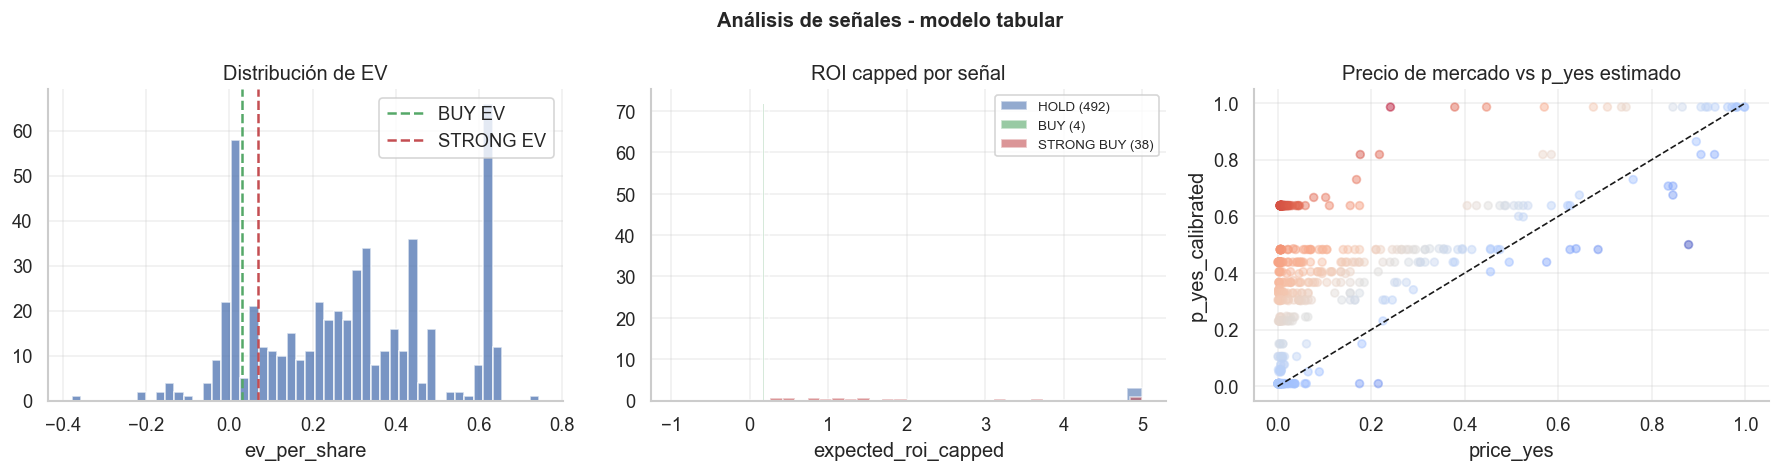

In [11]:
df_filtered = df_scores[df_scores['signal'].isin(['BUY', 'STRONG BUY'])].copy()

print(f'Señales finales: {len(df_filtered):,}')
print(f"  BUY:         {(df_filtered['signal'] == 'BUY').sum():,}")
print(f"  STRONG BUY:  {(df_filtered['signal'] == 'STRONG BUY').sum():,}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(df_scores['ev_per_share'], bins=50, color=PALETTE[0], alpha=0.75)
ax.axvline(cfg['scoring']['buy_ev_threshold'], color=PALETTE[2], linestyle='--', lw=1.5, label='BUY EV')
ax.axvline(cfg['scoring']['strong_buy_ev_threshold'], color=PALETTE[3], linestyle='--', lw=1.5, label='STRONG EV')
ax.set_title('Distribución de EV')
ax.set_xlabel('ev_per_share')
ax.legend()

ax = axes[1]
for signal, color in [('HOLD', PALETTE[0]), ('BUY', PALETTE[2]), ('STRONG BUY', PALETTE[3])]:
    sub = df_scores[df_scores['signal'] == signal]['expected_roi_capped']
    if len(sub) > 0:
        ax.hist(sub, bins=30, alpha=0.6, color=color, label=f'{signal} ({len(sub):,})', density=True)
ax.set_title('ROI capped por señal')
ax.set_xlabel('expected_roi_capped')
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(df_scores['price_yes'], df_scores['p_yes_calibrated'], c=df_scores['ev_per_share'], cmap='coolwarm', alpha=0.45, s=22)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('price_yes')
ax.set_ylabel('p_yes_calibrated')
ax.set_title('Precio de mercado vs p_yes estimado')

plt.suptitle('Análisis de señales - modelo tabular', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Desempeño offline en test

En lugar de reconstruir un backtest manual dentro del notebook, aquí leemos el mismo resumen offline que usa `model_comparison.json`.


In [12]:
bucket_rows = []
for bucket_name, bucket_payload in test_metrics.get('by_horizon', {}).items():
    bucket_rows.append({
        'bucket': bucket_name,
        'count': bucket_payload.get('count', 0),
        'brier': bucket_payload.get('probability_metrics', {}).get('brier'),
        'market_brier': bucket_payload.get('market_baseline_metrics', {}).get('brier'),
        'top_k_avg_realized_pnl': bucket_payload.get('ev_metrics', {}).get('top_k_avg_realized_pnl'),
        'top_k_hit_rate': bucket_payload.get('ev_metrics', {}).get('top_k_hit_rate'),
    })

df_bt = pd.DataFrame(bucket_rows)
display(df_bt.round(4))


,bucket,count,brier,market_brier,top_k_avg_realized_pnl,top_k_hit_rate
0,short_1_3d,2380,0.0092,0.0052,-0.0889,0.00
1,medium_4_14d,2380,0.0097,0.0052,-0.0289,0.00
2,long_15plus,1167,0.0177,0.0101,0.0438,0.15


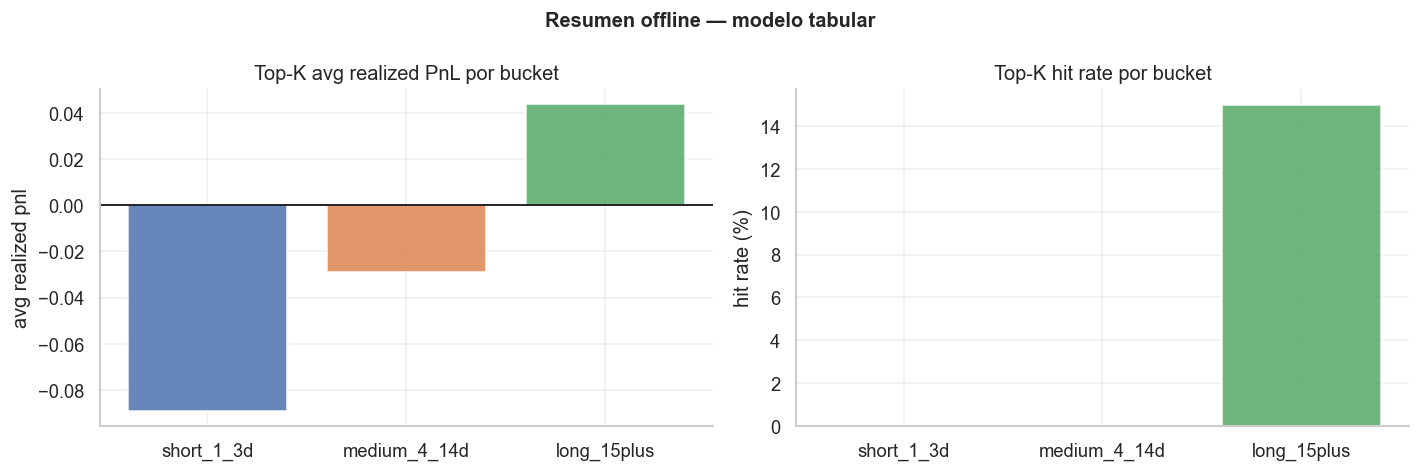

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(df_bt['bucket'], df_bt['top_k_avg_realized_pnl'], color=PALETTE[:len(df_bt)], alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.set_title('Top-K avg realized PnL por bucket')
ax.set_ylabel('avg realized pnl')

ax = axes[1]
ax.bar(df_bt['bucket'], 100 * df_bt['top_k_hit_rate'], color=PALETTE[:len(df_bt)], alpha=0.85)
ax.set_title('Top-K hit rate por bucket')
ax.set_ylabel('hit rate (%)')

plt.suptitle('Resumen offline — modelo tabular', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Resumen operativo


In [14]:
print('Lectura rápida:')
print(f"- El modelo tabular live emite {len(df_filtered):,} señales accionables.")
print(f"- En test, top_k_avg_realized_pnl = {test_metrics['ev_metrics']['top_k_avg_realized_pnl']:+.4f}.")
print(f"- En test, brier = {test_metrics['calibrated_metrics']['brier']:.4f} vs mercado {test_metrics['market_baseline_metrics']['brier']:.4f}.")
print('- Si el brier queda peor que mercado, úsalo solo como ranking auxiliar, no como probabilidad.')


Lectura rápida:
- El modelo tabular live emite 42 señales accionables.
- En test, top_k_avg_realized_pnl = +0.0267.
- En test, brier = 0.0111 vs mercado 0.0062.
- Si el brier queda peor que mercado, úsalo solo como ranking auxiliar, no como probabilidad.


In [15]:
print("Este notebook usa artefactos del scorer actual.")
print("Si quieres regenerarlos: ../.venv/bin/python -m src.scoring.scorer --config ../config/config.yaml --all-models")


Este notebook usa artefactos del scorer actual.
Si quieres regenerarlos: ../.venv/bin/python -m src.scoring.scorer --config ../config/config.yaml --all-models
